# 04 — Model Inference

This notebook evaluates the selected EfficientNet-B0 model on unseen images and analyzes its predictions.

In [5]:
# Imports
import os
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
!git clone https://github.com/gracyy-rm/autonomous-binary-classifier.git

Cloning into 'autonomous-binary-classifier'...
remote: Enumerating objects: 537, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 537 (delta 19), reused 25 (delta 9), pack-reused 498 (from 2)
Receiving objects: 100% (537/537), 268.99 MiB | 30.45 MiB/s, done.
Resolving deltas: 100% (288/288), done.
Updating files: 100% (60/60), done.


In [7]:
os.chdir("/kaggle/working/autonomous-binary-classifier")

In [8]:
from src.inference import BinaryClassifierInference

In [9]:
EXPERIMENTS_DIR = "/kaggle/input/datasets/gracyyadav79/experiments-models"
MODEL_PATH = os.path.join(
    EXPERIMENTS_DIR,
    "efficientnet_experiment",
    "efficientnet_b0_lr0.001_bs128_20260810_071818",
    "best_model_acc_91.5.pth"
)

In [10]:
INFERENCE_CSV = "/kaggle/input/datasets/gracyyadav79/inference-data/inference.csv"

## Load Selected Model

The EfficientNet-B0 checkpoint selected during model comparison is loaded for inference on unseen images.

In [11]:
inferencer = BinaryClassifierInference(model_path=MODEL_PATH)


--- Model Checkpoint Information ---
Model      : efficientnet_b0
Image Size : 224
Checkpoint : /kaggle/input/datasets/gracyyadav79/experiments-models/efficientnet_experiment/efficientnet_b0_lr0.001_bs128_20260810_071818/best_model_acc_91.5.pth
------------------------------------

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 131MB/s]


## Batch Inference

Batch inference is performed on the unseen dataset using the selected EfficientNet-B0 model.

In [12]:
predictions_df = inferencer.predict_csv_batch(
    csv_path=INFERENCE_CSV,
    batch_size=32,
    num_workers=4
)

predictions_df.head()


--- Starting Batch Inference on 514 images ---
Device: cpu | Model: efficientnet_b0 | Batch Size: 32 | Threshold: 0.5



Processing Batches: 100%|██████████| 17/17 [00:34<00:00,  2.01s/it]


Inference Complete! Processed 514 valid images.


,image_path,image_name,raw_logit,raw_prob,pred_label,pred_class_name,confidence_score,is_uncertain
0,/kaggle/input/datasets/gracyyadav79/data-2k-50...,9bc0e5c8-0cb9683d.jpg,22.3425,1.0,1,Obstacle,100.0,False
1,/kaggle/input/datasets/gracyyadav79/data-2k-50...,b7226661-33b4c4ff.jpg,13.5993,1.0,1,Obstacle,100.0,False
2,/kaggle/input/datasets/gracyyadav79/data-2k-50...,c6728701-f427d429.jpg,10.2992,1.0,1,Obstacle,100.0,False
3,/kaggle/input/datasets/gracyyadav79/data-2k-50...,a279854d-162bd02c.jpg,21.8656,1.0,1,Obstacle,100.0,False
4,/kaggle/input/datasets/gracyyadav79/data-2k-50...,25ff9422-84463d87.jpg,10.4630,1.0,1,Obstacle,100.0,False


## Prediction Summary

The distribution of predicted classes and model confidence is examined to understand the behavior of the selected model on unseen images.

In [13]:
print(predictions_df["pred_class_name"].value_counts())
print(f"\nTotal Images: {len(predictions_df)}")

pred_class_name
Obstacle       318
No Obstacle    196
Name: count, dtype: int64

Total Images: 514


In [14]:
print("Uncertain Predictions")

print(predictions_df["is_uncertain"].value_counts())

Uncertain Predictions
is_uncertain
False    501
True      13
Name: count, dtype: int64


In [15]:
prediction_distribution = (
    predictions_df["pred_class_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

prediction_distribution

pred_class_name
Obstacle       61.87
No Obstacle    38.13
Name: proportion, dtype: float64


Displaying Grid: Random Sample Predictions (16 images)...


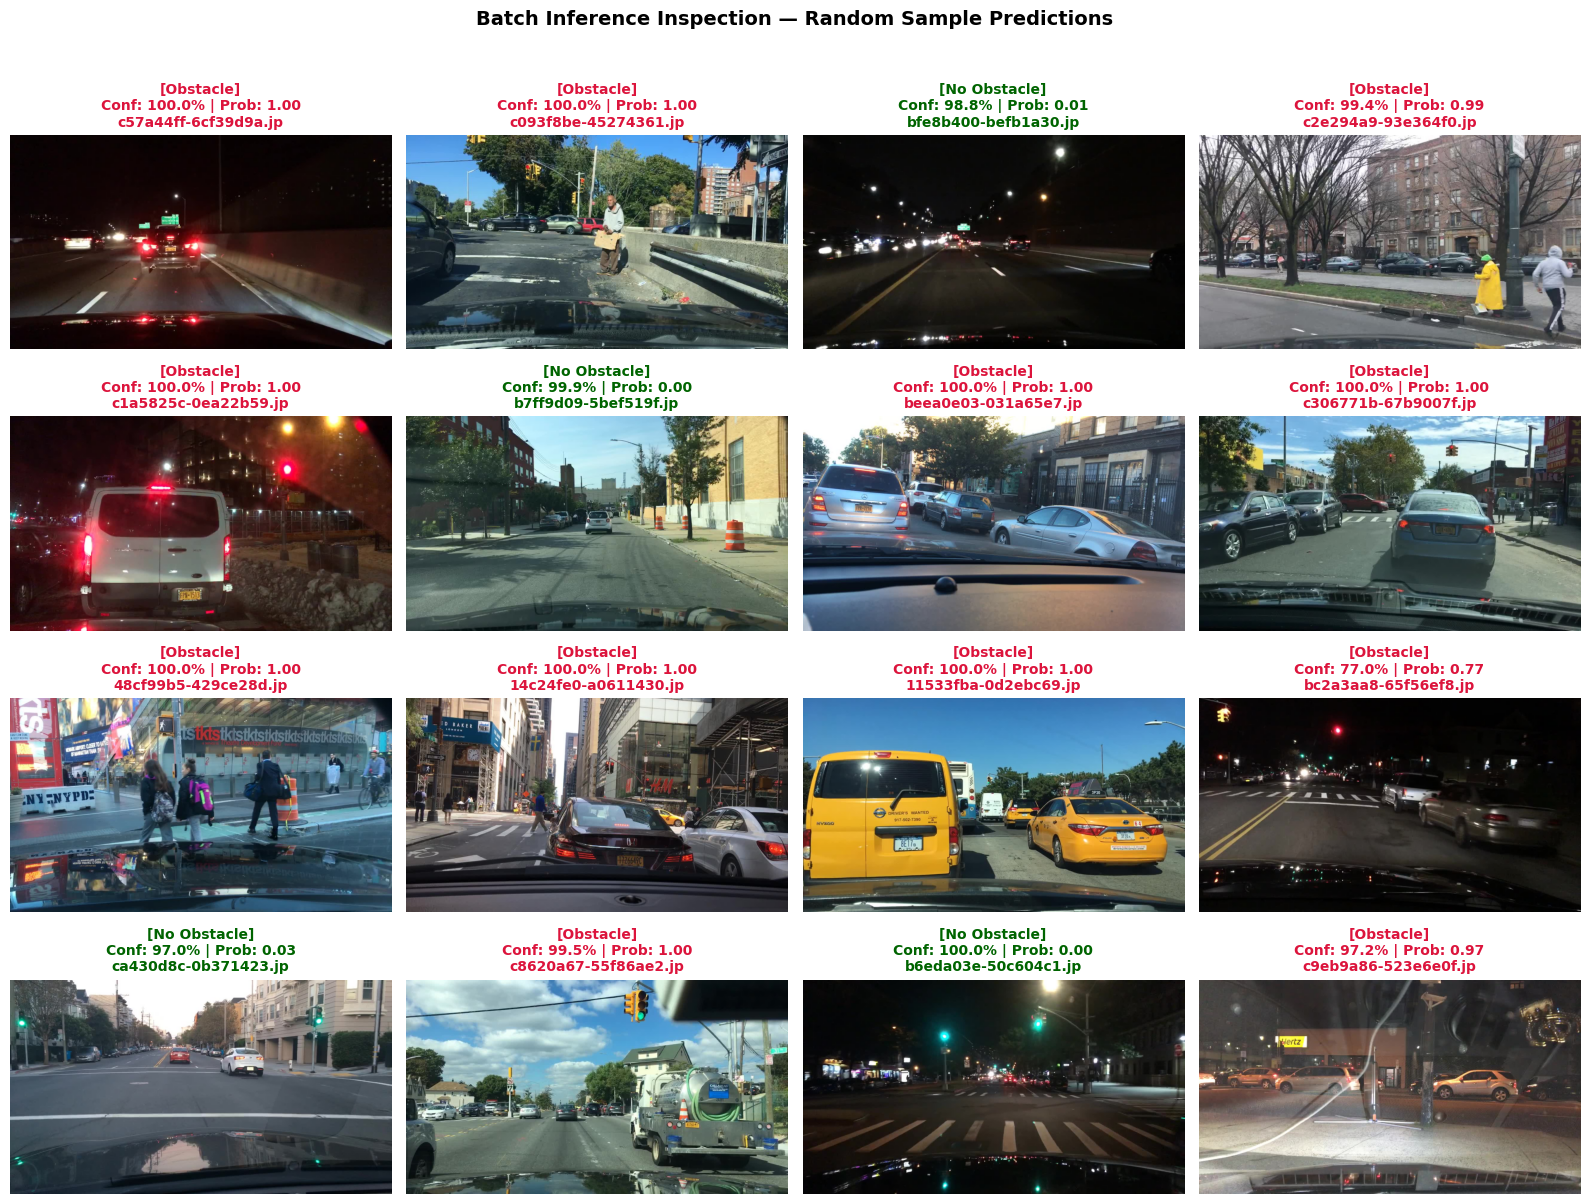

In [16]:
inferencer.visualize_predictions_grid(
    predictions_df,
    filter_type="random",
    num_samples=16
)


Displaying Grid: Most Uncertain / Low-Confidence Predictions (16 images)...


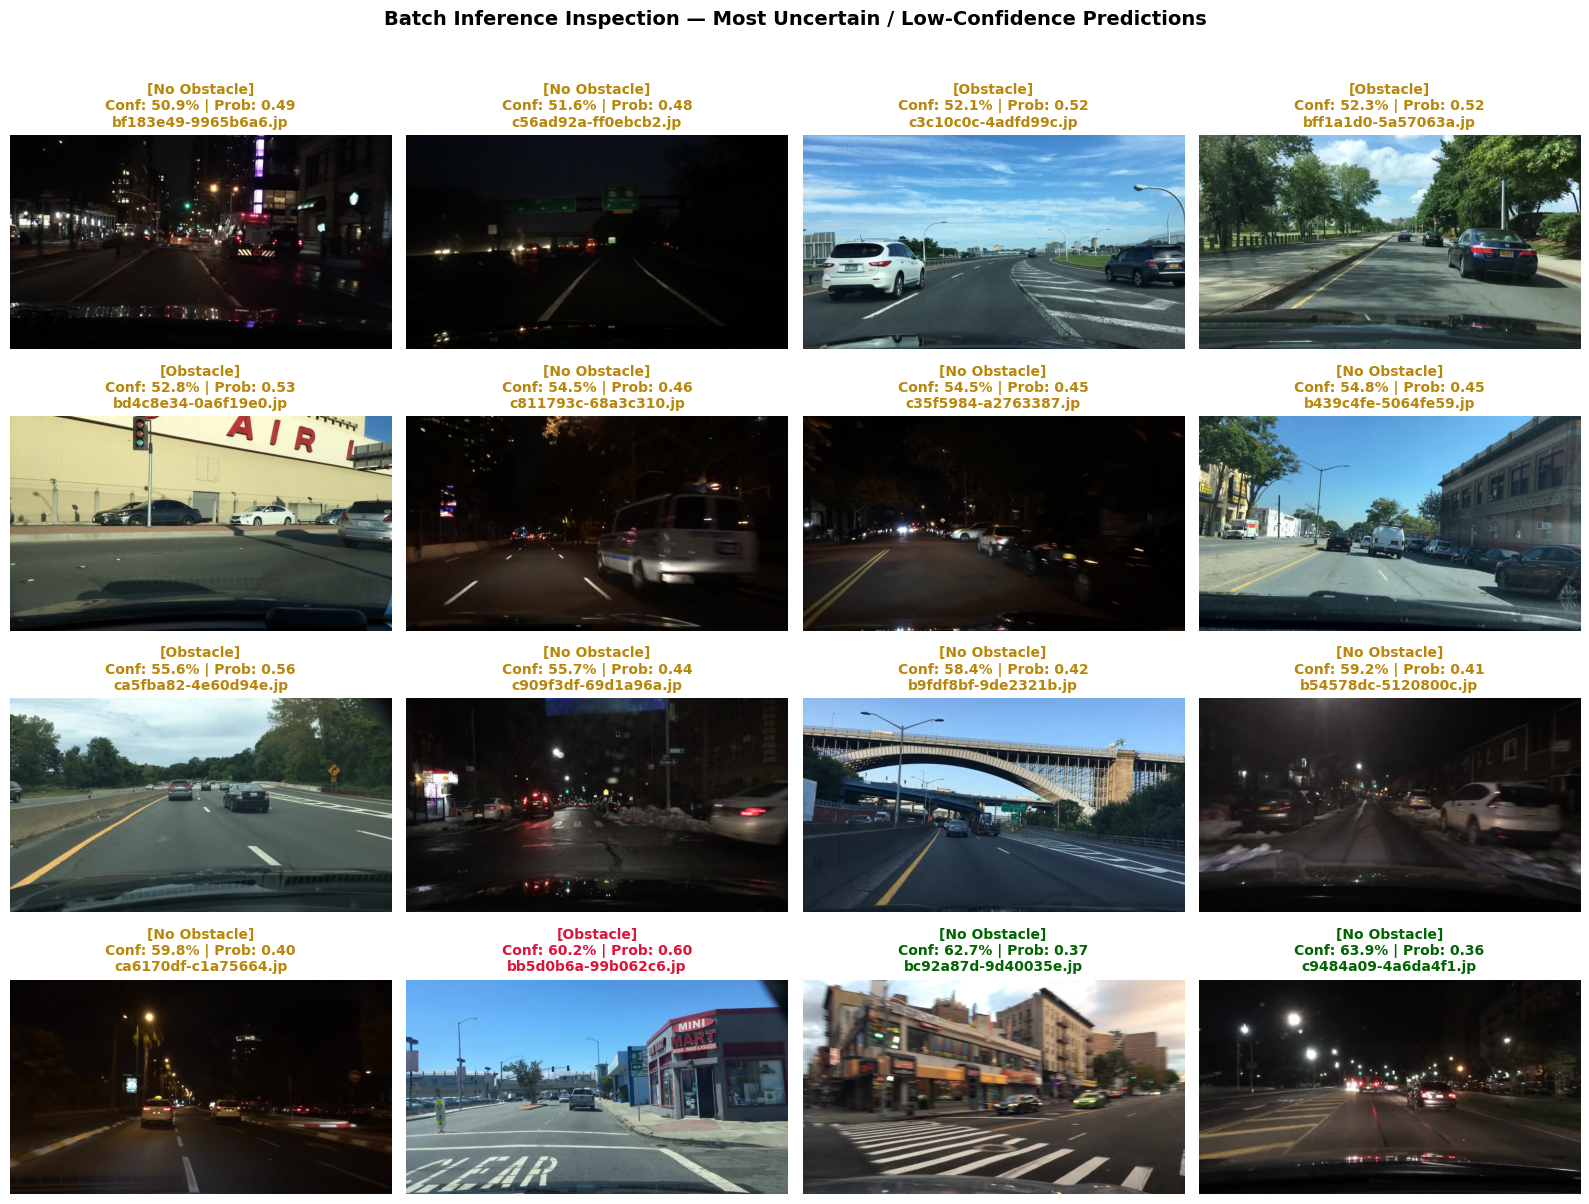

In [17]:
inferencer.visualize_predictions_grid(
    predictions_df,
    filter_type="uncertain",
    num_samples=16
)

## Graphs

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


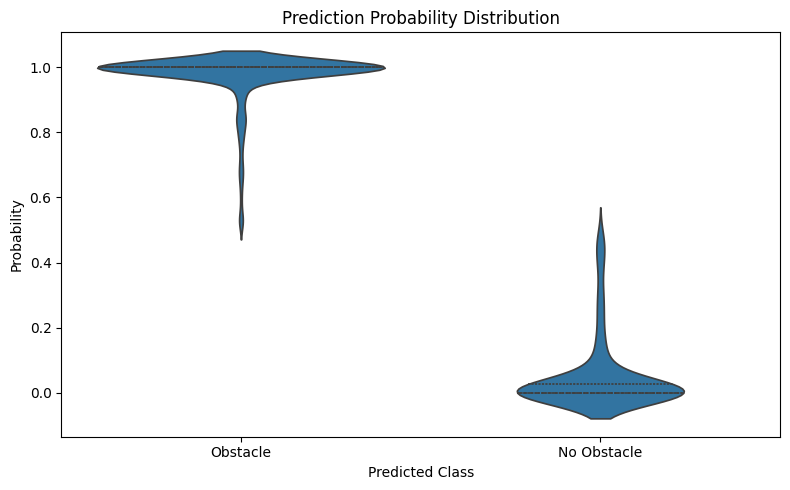

In [22]:
plt.figure(figsize=(8,5))
sns.violinplot(data=predictions_df,x="pred_class_name",y="raw_prob",inner="quartile")
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

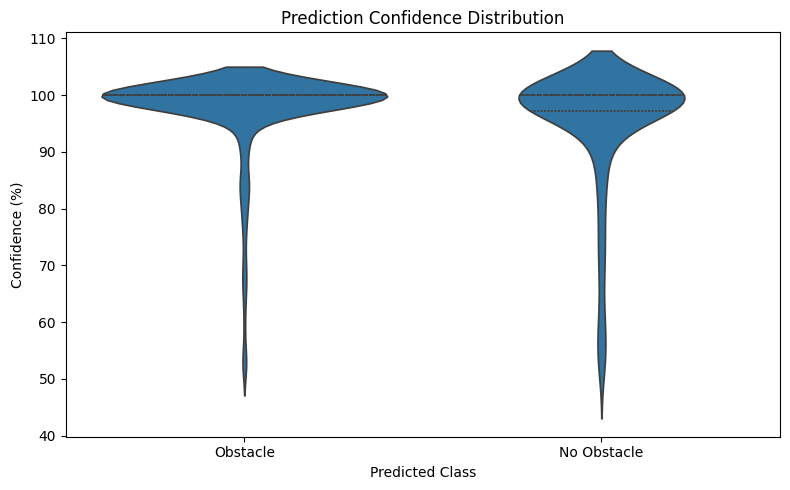

In [23]:
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=predictions_df,
    x="pred_class_name",
    y="confidence_score",
    inner="quartile"
)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Confidence (%)")
plt.tight_layout()
plt.show()

## Save Inference Results

The predictions generated by the selected model are saved for further analysis and Grad-CAM visualization.

In [40]:
os.chdir("/kaggle/working")

In [41]:
!pwd

/kaggle/working


In [42]:
OUTPUT_PATH = "efficientnet_b0_inference_results.csv"

predictions_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Inference results saved to: {OUTPUT_PATH}")

Inference results saved to: efficientnet_b0_inference_results.csv
